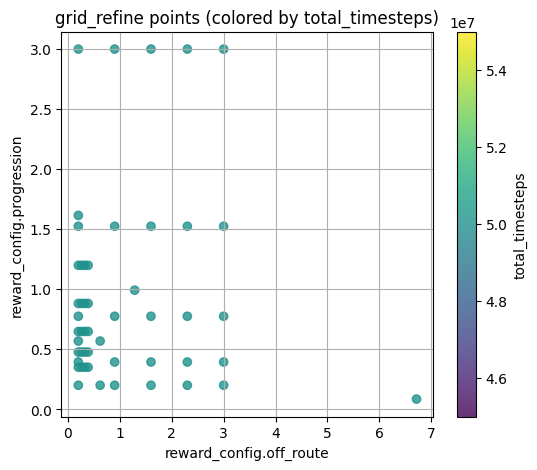

Best point: reward_config.off_route 0.2 reward_config.progression 0.7745966692414834 grade= 0.809878957771172


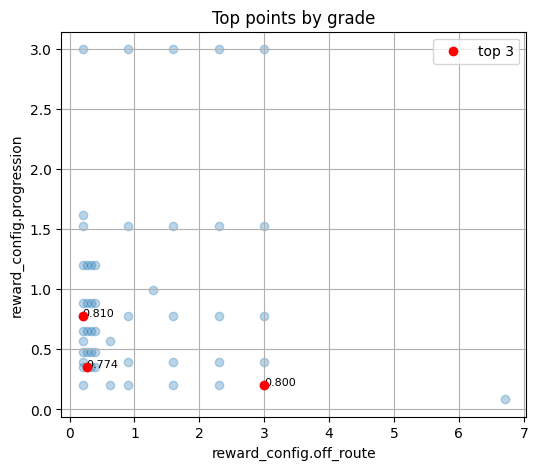

In [18]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# === Config ===
# Change this to your stage1 run folder
root_run_dir = Path('/home/rtgtx7/Desktop/AD/v-max/runs/PPO_VEC_MLP_05-12_11:22:58')
trials_csv = root_run_dir / 'map_db' / 'trials_long.csv'

if not trials_csv.exists() or trials_csv.stat().st_size == 0:
    # Fake grid_refine data (more realistic):
    # - Round 1: full 5x5 grid
    # - Later rounds: still 5x5 but centered on best w/ noise
    import numpy as np
    rng = np.random.default_rng(0)
    rounds = 4
    grid_points_by_round = [5, 3, 2, 2]
    x_range = (0, 3.0)
    y_range = (0, 3.0)
    best = (1.6, 1.2)
    data = []
    for r in range(rounds):
        shrink = 0.6** r
        # center drifts slightly each round (simulating noisy best)
        center_x = best[0] + rng.normal(0, 0.05)
        center_y = best[1] + rng.normal(0, 0.05)
        span_x = (x_range[1] - x_range[0]) * shrink
        span_y = (y_range[1] - y_range[0]) * shrink
        x_low = max(x_range[0], center_x - span_x / 2)
        x_high = min(x_range[1], center_x + span_x / 2)
        y_low = max(y_range[0], center_y - span_y / 2)
        y_high = min(y_range[1], center_y + span_y / 2)
        grid_points = grid_points_by_round[min(r, len(grid_points_by_round) - 1)]
        xs = np.linspace(x_low, x_high, grid_points)
        ys = np.linspace(y_low, y_high, grid_points)
        for x in xs:
            for y in ys:
                # grade peak near (1.6,1.2) + noise
                grade = 1.0 / (1.0 + abs(x-1.6) + abs(y-1.2)) + rng.normal(0, 0.01)
                data.append({
                    'overrides': json.dumps([f'reward_config.off_route={x:.4f}', f'reward_config.progression={y:.4f}']),
                    'total_timesteps': 20000000 + r * 15000000,
                    'grade': grade
                })
    df = pd.DataFrame(data)
else:
    df = pd.read_csv(trials_csv)

# Parse overrides to extract two reward parameters
def parse_overrides(s):
    try:
        items = json.loads(s)
    except Exception:
        return {}
    out = {}
    for ov in items:
        if '=' not in ov:
            continue
        k, v = ov.split('=', 1)
        try:
            v = float(v)
        except Exception:
            pass
        out[k] = v
    return out

ov = df['overrides'].apply(parse_overrides)

# Pick your two parameters (change if needed)
x_key = 'reward_config.off_route'
y_key = 'reward_config.progression'

df['x'] = ov.apply(lambda d: d.get(x_key))
df['y'] = ov.apply(lambda d: d.get(y_key))

# Basic scatter: colored by total_timesteps (budget)
plt.figure(figsize=(6, 5))
sc = plt.scatter(df['x'], df['y'], c=df['total_timesteps'], cmap='viridis', alpha=0.8)
plt.xlabel(x_key)
plt.ylabel(y_key)
plt.title('grid_refine points (colored by total_timesteps)')
plt.colorbar(sc, label='total_timesteps')
plt.grid(True)
plt.show()


# Show global best (from best.yaml) if it exists
best_yaml = root_run_dir / 'map_db' / 'best.yaml'
if best_yaml.exists():
    import yaml
    best = yaml.safe_load(best_yaml.read_text())
    best_overrides = best.get('ready_overrides', [])
    best_map = {}
    for ov in best_overrides:
        if '=' not in ov:
            continue
        k, v = ov.split('=', 1)
        try:
            best_map[k] = float(v)
        except Exception:
            pass
    if x_key in best_map and y_key in best_map:
        plt.figure(figsize=(6, 5))
        plt.scatter(df['x'], df['y'], alpha=0.3)
        plt.scatter([best_map[x_key]], [best_map[y_key]], color='red', label='global best', zorder=5)
        plt.xlabel(x_key)
        plt.ylabel(y_key)
        plt.title('Global best point (from best.yaml)')
        plt.legend()
        plt.grid(True)
        plt.show()

# If grade exists, highlight best points
if 'grade' in df.columns:
    best = df.sort_values('grade', ascending=False).head(3)
    best_one = df.sort_values('grade', ascending=False).iloc[0]
    print('Best point:', x_key, best_one['x'], y_key, best_one['y'], 'grade=', best_one['grade'])
    plt.figure(figsize=(6, 5))
    plt.scatter(df['x'], df['y'], alpha=0.3)
    plt.scatter(best['x'], best['y'], color='red', label='top 3', zorder=5)
    for _, row in best.iterrows():
        plt.text(row['x'], row['y'], f"{row['grade']:.3f}", fontsize=8)
    plt.xlabel(x_key)
    plt.ylabel(y_key)
    plt.title('Top points by grade')
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
# 3D Grade Surface (topography)
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib.tri import Triangulation

# Load latest trials
import pandas as pd
from pathlib import Path
df = pd.read_csv(trials_csv)
# extract params
def _get_val(s, key):
    for part in str(s).split('|'):
        if part.startswith(key+'='):
            return float(part.split('=',1)[1])
    return None
if 'reward_config.off_route' in df.columns:
    df['x'] = pd.to_numeric(df['reward_config.off_route'], errors='coerce')
else:
    df['x'] = df.get('param_vector','').apply(lambda s: _get_val(s, 'reward_config.off_route'))
if 'reward_config.progression' in df.columns:
    df['y'] = pd.to_numeric(df['reward_config.progression'], errors='coerce')
else:
    df['y'] = df.get('param_vector','').apply(lambda s: _get_val(s, 'reward_config.progression'))
if 'grade' not in df.columns or df['grade'].isna().all():
    if 'vmax_aggregate_score' in df.columns and 'nuplan_aggregate_score' in df.columns:
        df['grade'] = 0.5*pd.to_numeric(df['vmax_aggregate_score'], errors='coerce') + 0.5*pd.to_numeric(df['nuplan_aggregate_score'], errors='coerce')
df = df.dropna(subset=['x','y','grade'])
x = df['x'].to_numpy()
y = df['y'].to_numpy()
z = df['grade'].to_numpy()

fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(x, y, z, cmap='viridis', alpha=0.85)
ax.scatter(x, y, z, c='black', s=12)
ax.set_xlabel('reward_config.off_route')
ax.set_ylabel('reward_config.progression')
ax.set_zlabel('grade')
ax.set_title('3D Grade Surface')
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'runs/PPO_VEC_MLP_05-12_11:22:58/map_db/trials_long.csv'

Final run best: reward_config.off_route 0.8300000000000001 reward_config.progression 1.4045966692414833 grade= 0.5066222343001631


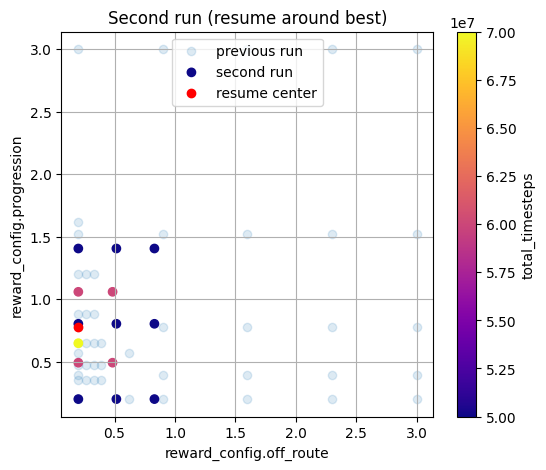

In [ ]:
# Simulate a second run that resumes around the global best
import numpy as np
import json
import pandas as pd

# Fake previous trials (or use existing df from cell 1)
prev = df.copy()

# Find best point from previous run
best_row = prev.sort_values('grade', ascending=False).iloc[0]
best_overrides = json.loads(best_row['overrides'])
best_map = {}
for ov in best_overrides:
    if '=' in ov:
        k, v = ov.split('=', 1)
        try:
            best_map[k] = float(v)
        except Exception:
            pass

x0 = best_map.get(x_key, df['x'].median())
y0 = best_map.get(y_key, df['y'].median())

# Second run settings
grid_points_by_round = [3, 2, 1]
shrink = 0.45
rounds = len(grid_points_by_round)
x_range = (0.2, 3.0)
y_range = (0.2, 3.0)

data2 = []
for r in range(rounds):
    span_x = (x_range[1] - x_range[0]) * (shrink ** (r + 1))
    span_y = (y_range[1] - y_range[0]) * (shrink ** (r + 1))
    x_low = max(x_range[0], x0 - span_x / 2)
    x_high = min(x_range[1], x0 + span_x / 2)
    y_low = max(y_range[0], y0 - span_y / 2)
    y_high = min(y_range[1], y0 + span_y / 2)
    gp = grid_points_by_round[r]
    xs = np.linspace(x_low, x_high, gp)
    ys = np.linspace(y_low, y_high, gp)
    for x in xs:
        for y in ys:
            grade = 1.0 / (1.0 + abs(x-1.6) + abs(y-1.2)) + np.random.normal(0, 0.01)
            data2.append({
                'x': x,
                'y': y,
                'total_timesteps': 50000000 + r * 10000000,
                'grade': grade
            })

df2 = pd.DataFrame(data2)
best2 = df2.sort_values('grade', ascending=False).iloc[0]
print('Final run best:', x_key, best2['x'], y_key, best2['y'], 'grade=', best2['grade'])

plt.figure(figsize=(6,5))
plt.scatter(prev['x'], prev['y'], alpha=0.15, label='previous run')
sc = plt.scatter(df2['x'], df2['y'], c=df2['total_timesteps'], cmap='plasma', label='second run')
plt.scatter([x0], [y0], color='red', label='resume center', zorder=5)
plt.xlabel(x_key)
plt.ylabel(y_key)
plt.title('Second run (resume around best)')
plt.colorbar(sc, label='total_timesteps')
plt.legend()
plt.grid(True)
plt.show()


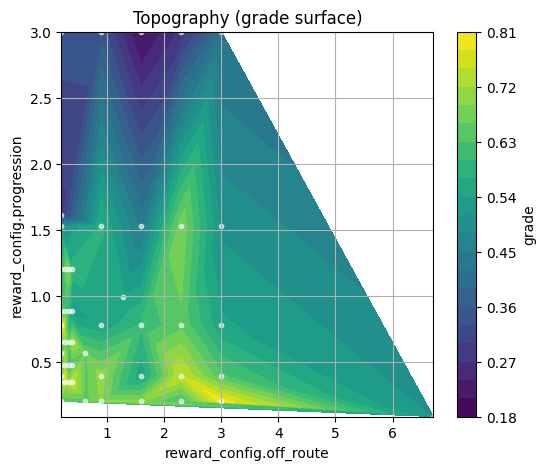

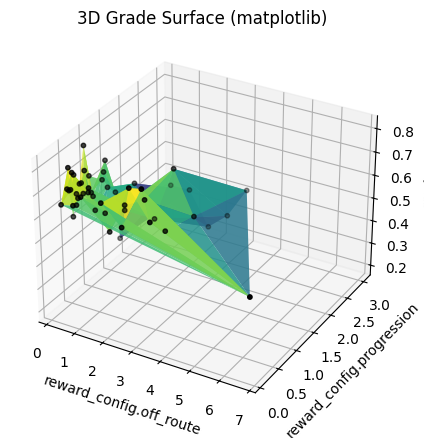

In [ ]:
# Dynamic heatmap + 3D + topography from existing points
import numpy as np
import matplotlib.pyplot as plt

# Use df from previous cells
if 'grade' not in df.columns:
    raise ValueError('grade column not found in df')

# --- Topography map (tricontourf) ---
plt.figure(figsize=(6,5))
tri = plt.tricontourf(df['x'], df['y'], df['grade'], levels=20, cmap='viridis')
plt.scatter(df['x'], df['y'], s=10, c='white', alpha=0.6)
plt.colorbar(tri, label='grade')
plt.xlabel(x_key)
plt.ylabel(y_key)
plt.title('Topography (grade surface)')
plt.grid(True)
plt.show()

# --- 3D surface (matplotlib) ---
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(df['x'], df['y'], df['grade'], cmap='viridis', alpha=0.85)
ax.scatter(df['x'], df['y'], df['grade'], s=10, c='black')
ax.set_xlabel(x_key)
ax.set_ylabel(y_key)
ax.set_zlabel('grade')
ax.set_title('3D Grade Surface (matplotlib)')
plt.show()

# --- Interactive 3D (Plotly if available) ---
try:
    import plotly.express as px
    fig = px.scatter_3d(df, x='x', y='y', z='grade', color='grade', title='Interactive 3D (Plotly)')
    fig.update_traces(marker=dict(size=3))
    fig.show()
except Exception as e:
    print('Plotly not available:', e)


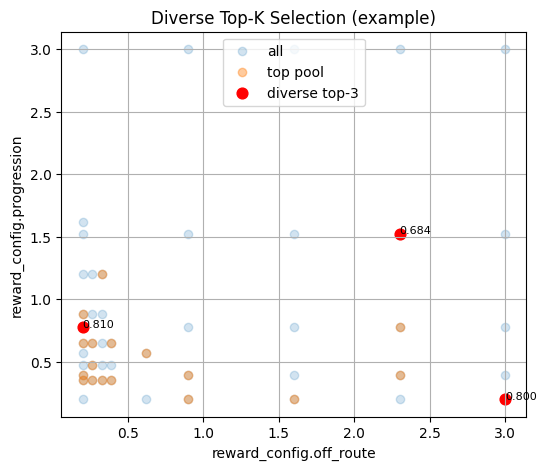

In [ ]:
# Visualize diverse top-K selection
import numpy as np

def diverse_top_k(points, ranges, k=3):
    if not points: return []
    selected = [points[0]]
    while len(selected) < min(k, len(points)):
        best = None
        best_dist = -1.0
        for p in points:
            if p in selected: continue
            dmin = 1e9
            for s in selected:
                dist = 0.0
                for key, (low, high) in ranges.items():
                    span = max(high - low, 1e-9)
                    dist += ((p[key]-s[key])/span) ** 2
                dist = dist**0.5
                dmin = min(dmin, dist)
            if dmin > best_dist:
                best_dist = dmin
                best = p
        if best is None: break
        selected.append(best)
    return selected

# Build candidate list from current df (top by grade)
cand = df.sort_values('grade', ascending=False).head(20)
points = [{'x': r['x'], 'y': r['y'], 'grade': r['grade']} for _, r in cand.iterrows()]
ranges = {
    'x': (df['x'].min(), df['x'].max()),
    'y': (df['y'].min(), df['y'].max()),
}
selected = diverse_top_k(points, ranges, k=3)

plt.figure(figsize=(6,5))
plt.scatter(df['x'], df['y'], alpha=0.2, label='all')
plt.scatter(cand['x'], cand['y'], alpha=0.4, label='top pool')
plt.scatter([p['x'] for p in selected], [p['y'] for p in selected], color='red', s=60, label='diverse top-3')
for p in selected:
    plt.text(p['x'], p['y'], f"{p['grade']:.3f}", fontsize=8)
plt.xlabel(x_key)
plt.ylabel(y_key)
plt.title('Diverse Top-K Selection (example)')
plt.legend()
plt.grid(True)
plt.show()


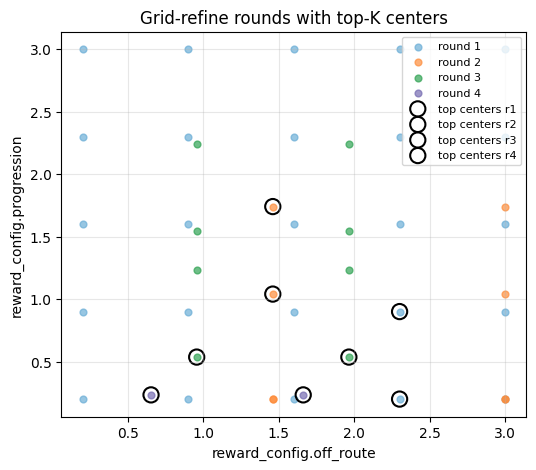

In [ ]:
# Grid-refine logic visualization (round-by-round)
import numpy as np
import matplotlib.pyplot as plt

# Example config (edit to match reward_space.json)
low = np.array([0.2, 0.2])
high = np.array([3.0, 3.0])
shrink = 0.6
# Per-round grid points (can decrease to save compute)
# Example: first round coarse 5x5, then 4x4, then 3x3
grid_points_by_round = [5, 2, 2, 1]
# Choose how many top centers to refine each round
refine_top_k = 2
# Merge nearby centers to avoid duplicate neighborhoods
merge_radius = 0.2  # in normalized [0,1] space

# Fake score surface for visualization (replace with real grades if available)
def score_fn(x, y):
    # Two peaks to show multi-center refinement
    return (
        0.6*np.exp(-((x-0.6)**2+(y-0.7)**2)/0.08) +
        0.55*np.exp(-((x-2.4)**2+(y-0.5)**2)/0.12) +
        0.15*np.exp(-((x-1.6)**2+(y-1.8)**2)/0.25)
    )

# Helpers
ranges = np.vstack([low, high])

def normalize(pt):
    return (pt - low) / (high - low)

def merge_centers(centers, radius):
    if not centers:
        return []
    kept = [centers[0]]
    for c in centers[1:]:
        if all(np.linalg.norm(normalize(c) - normalize(k)) > radius for k in kept):
            kept.append(c)
    return kept

# Start with global box center
centers = [0.5*(low+high)]
all_points = []
round_centers = []

for r, gp in enumerate(grid_points_by_round, start=1):
    round_pts = []
    for c in centers:
        span = (high - low) * (shrink**(r-1))
        lo = np.maximum(low, c - 0.5*span)
        hi = np.minimum(high, c + 0.5*span)
        xs = np.linspace(lo[0], hi[0], gp)
        ys = np.linspace(lo[1], hi[1], gp)
        for x in xs:
            for y in ys:
                round_pts.append((x, y))
    # score and pick top-k
    scored = sorted([(score_fn(x,y), (x,y)) for (x,y) in round_pts], reverse=True)
    top = [pt for _, pt in scored[:refine_top_k]]
    top = merge_centers(top, merge_radius)

    all_points.append(round_pts)
    round_centers.append(top)
    centers = top if top else centers

# Plot all rounds
fig, ax = plt.subplots(figsize=(6,5))
colors = ['#6baed6', '#fd8d3c', '#31a354', '#756bb1']
for i, pts in enumerate(all_points):
    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]
    ax.scatter(xs, ys, s=24, alpha=0.7, label=f'round {i+1}', color=colors[i%len(colors)])

# Mark chosen centers each round
for i, centers in enumerate(round_centers):
    xs = [p[0] for p in centers]
    ys = [p[1] for p in centers]
    ax.scatter(xs, ys, s=120, edgecolor='black', facecolor='none', linewidth=1.5, label=f'top centers r{i+1}')

ax.set_xlabel('reward_config.off_route')
ax.set_ylabel('reward_config.progression')
ax.set_title('Grid-refine rounds with top-K centers')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
plt.show()


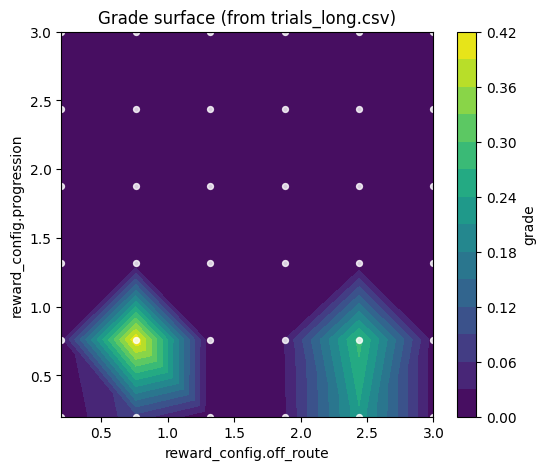

In [ ]:
# Grade surface from real trials_long.csv (fallback to fake if empty)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation

trials_csv = Path('runs/PPO_VEC_MLP_05-12_11:22:58/map_db/trials_long.csv')
if trials_csv.exists() and trials_csv.stat().st_size > 0:
    df = pd.read_csv(trials_csv)
    # Use grade if present, else compute from vmax/nuplan
    if 'grade' not in df.columns:
        if {'vmax_aggregate_score','nuplan_aggregate_score'}.issubset(df.columns):
            df['grade'] = 0.5*df['vmax_aggregate_score'] + 0.5*df['nuplan_aggregate_score']
    # Extract reward params from overrides_str
    def _get_val(s, key):
        for part in str(s).split('|'):
            if part.startswith(key+'='):
                return float(part.split('=',1)[1])
        return np.nan
    df['off_route'] = df['overrides_str'].apply(lambda s: _get_val(s, 'reward_config.off_route'))
    df['progression'] = df['overrides_str'].apply(lambda s: _get_val(s, 'reward_config.progression'))
    df = df.dropna(subset=['off_route','progression','grade'])
else:
    # Fake example if no data yet
    xs = np.linspace(0.2,3.0,6)
    ys = np.linspace(0.2,3.0,6)
    X,Y = np.meshgrid(xs,ys)
    Z = 0.6*np.exp(-((X-0.7)**2+(Y-0.6)**2)/0.08) + 0.5*np.exp(-((X-2.4)**2+(Y-0.5)**2)/0.12)
    df = pd.DataFrame({'off_route':X.ravel(),'progression':Y.ravel(),'grade':Z.ravel()})

fig, ax = plt.subplots(figsize=(6,5))
tri = Triangulation(df['off_route'], df['progression'])
cntr = ax.tricontourf(tri, df['grade'], levels=14, cmap='viridis')
ax.scatter(df['off_route'], df['progression'], c='white', s=18, alpha=0.8)
ax.set_xlabel('reward_config.off_route')
ax.set_ylabel('reward_config.progression')
ax.set_title('Grade surface (from trials_long.csv)')
plt.colorbar(cntr, ax=ax, label='grade')
plt.show()


In [15]:
# Cost estimate with fixed 50M per point and K=2 branches
import numpy as np

budget_per_point = 50_000_000
K = 2
# Example: coarse -> fine points per round (edit)
grid_points_by_round = [5, 2, 2, 1]

# round 1 has 1 center, later rounds use K centers
points_per_round = []
for i, gp in enumerate(grid_points_by_round):
    centers = 1 if i == 0 else K
    points = centers * (gp * gp)
    points_per_round.append(points)

print('grid_points_by_round:', grid_points_by_round)
print('points_per_round:', points_per_round)
print('total_points:', sum(points_per_round))
print('total_steps:', sum(points_per_round) * budget_per_point)
print('total_steps (billions):', sum(points_per_round) * budget_per_point / 1e9)


grid_points_by_round: [5, 2, 2, 1]
points_per_round: [25, 8, 8, 2]
total_points: 43
total_steps: 2150000000
total_steps (billions): 2.15
